# Gradient Flows with Different Metrics

We compare implicit proximal steps with metric term $\|x-x_k\|_p^2$ for several $p$.

A gradient depends on the geometry used to measure steepness. With a positive-definite metric $G(x)$, the flow becomes
$$\dot x=-G(x)^{-1}\nabla f(x).$$
Although each trajectory decreases the same objective, different metrics precondition directions and change the path and convergence speed. The comparison makes this coordinate dependence visible.

Because objective values alone can hide this geometric effect, the trajectories are drawn on common level sets. Their shapes reveal how preconditioning redirects motion through anisotropic valleys.


## Objective and metric choices


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

OUT = Path(".")
A = np.array([[8.0, 1.5], [1.5, 1.2]])
f = lambda x: 0.5 * np.einsum("...i,ij,...j->...", x, A, x)
grad = lambda x: x @ A.T

G_euclid = np.eye(2)
G_aniso = np.array([[4.0, 0.0], [0.0, 0.7]])
Ginv_e = np.linalg.inv(G_euclid)
Ginv_a = np.linalg.inv(G_aniso)

x0 = np.array([1.8, -1.4])
dt = 0.055
steps = 150

def integrate(Ginv):
    X = np.zeros((steps + 1, 2))
    X[0] = x0
    for k in range(steps):
        X[k + 1] = X[k] - dt * (Ginv @ grad(X[k]))
    return X

Xe = integrate(Ginv_e)
Xa = integrate(Ginv_a)


## Trajectory comparison

# implicit-prox interpretation: x_{k+1}=argmin ||x-x_k||_p^2 + tau||x-y||_2^2


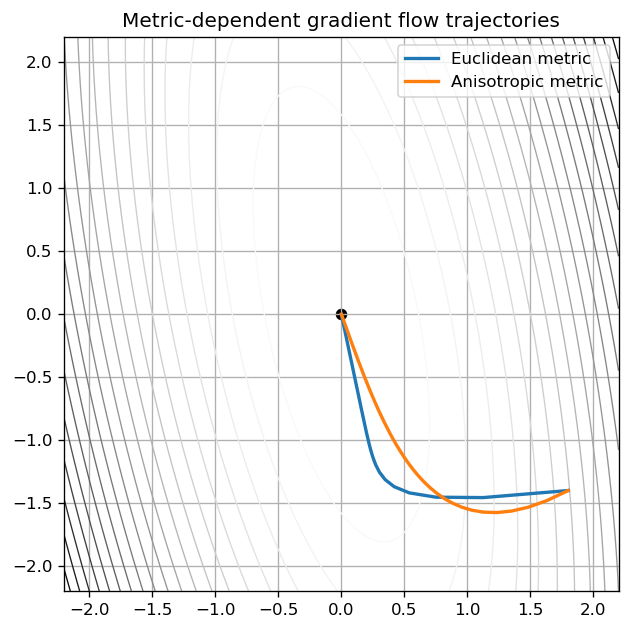

In [2]:
xx = np.linspace(-2.2, 2.2, 220)
yy = np.linspace(-2.2, 2.2, 220)
XX, YY = np.meshgrid(xx, yy)
P = np.stack([XX, YY], axis=-1)
FF = f(P)

fig, ax = plt.subplots(figsize=(6.6, 6.0))
ax.contour(XX, YY, FF, levels=20, cmap="Greys", linewidths=0.8)
ax.plot(Xe[:,0], Xe[:,1], color="tab:blue", lw=2, label="Euclidean metric")
ax.plot(Xa[:,0], Xa[:,1], color="tab:orange", lw=2, label="Anisotropic metric")
ax.scatter([0], [0], c="k", s=35)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Metric-dependent gradient flow trajectories")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical resources

- Ambrosio, L., Gigli, N., and Savare, G. (2008). *Gradient Flows in Metric Spaces and in the Space of Probability Measures*. Birkhauser.
- Jordan, R., Kinderlehrer, D., and Otto, F. (1998). The variational formulation of the Fokker--Planck equation. *SIAM Journal on Mathematical Analysis*, 29, 1--17.
- Santambrogio, F. (2017). Euclidean, metric, and Wasserstein gradient flows: an overview. *Bulletin of Mathematical Sciences*, 7, 87--154.